In [42]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [43]:
df = pd.read_csv('train.csv')

In [44]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [45]:
df.isna().sum().sum()

np.int64(0)

In [46]:
df.drop_duplicates(inplace=True)

In [47]:
df['price_range'].value_counts().sort_index()

price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64

In [48]:
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features.remove('price_range')

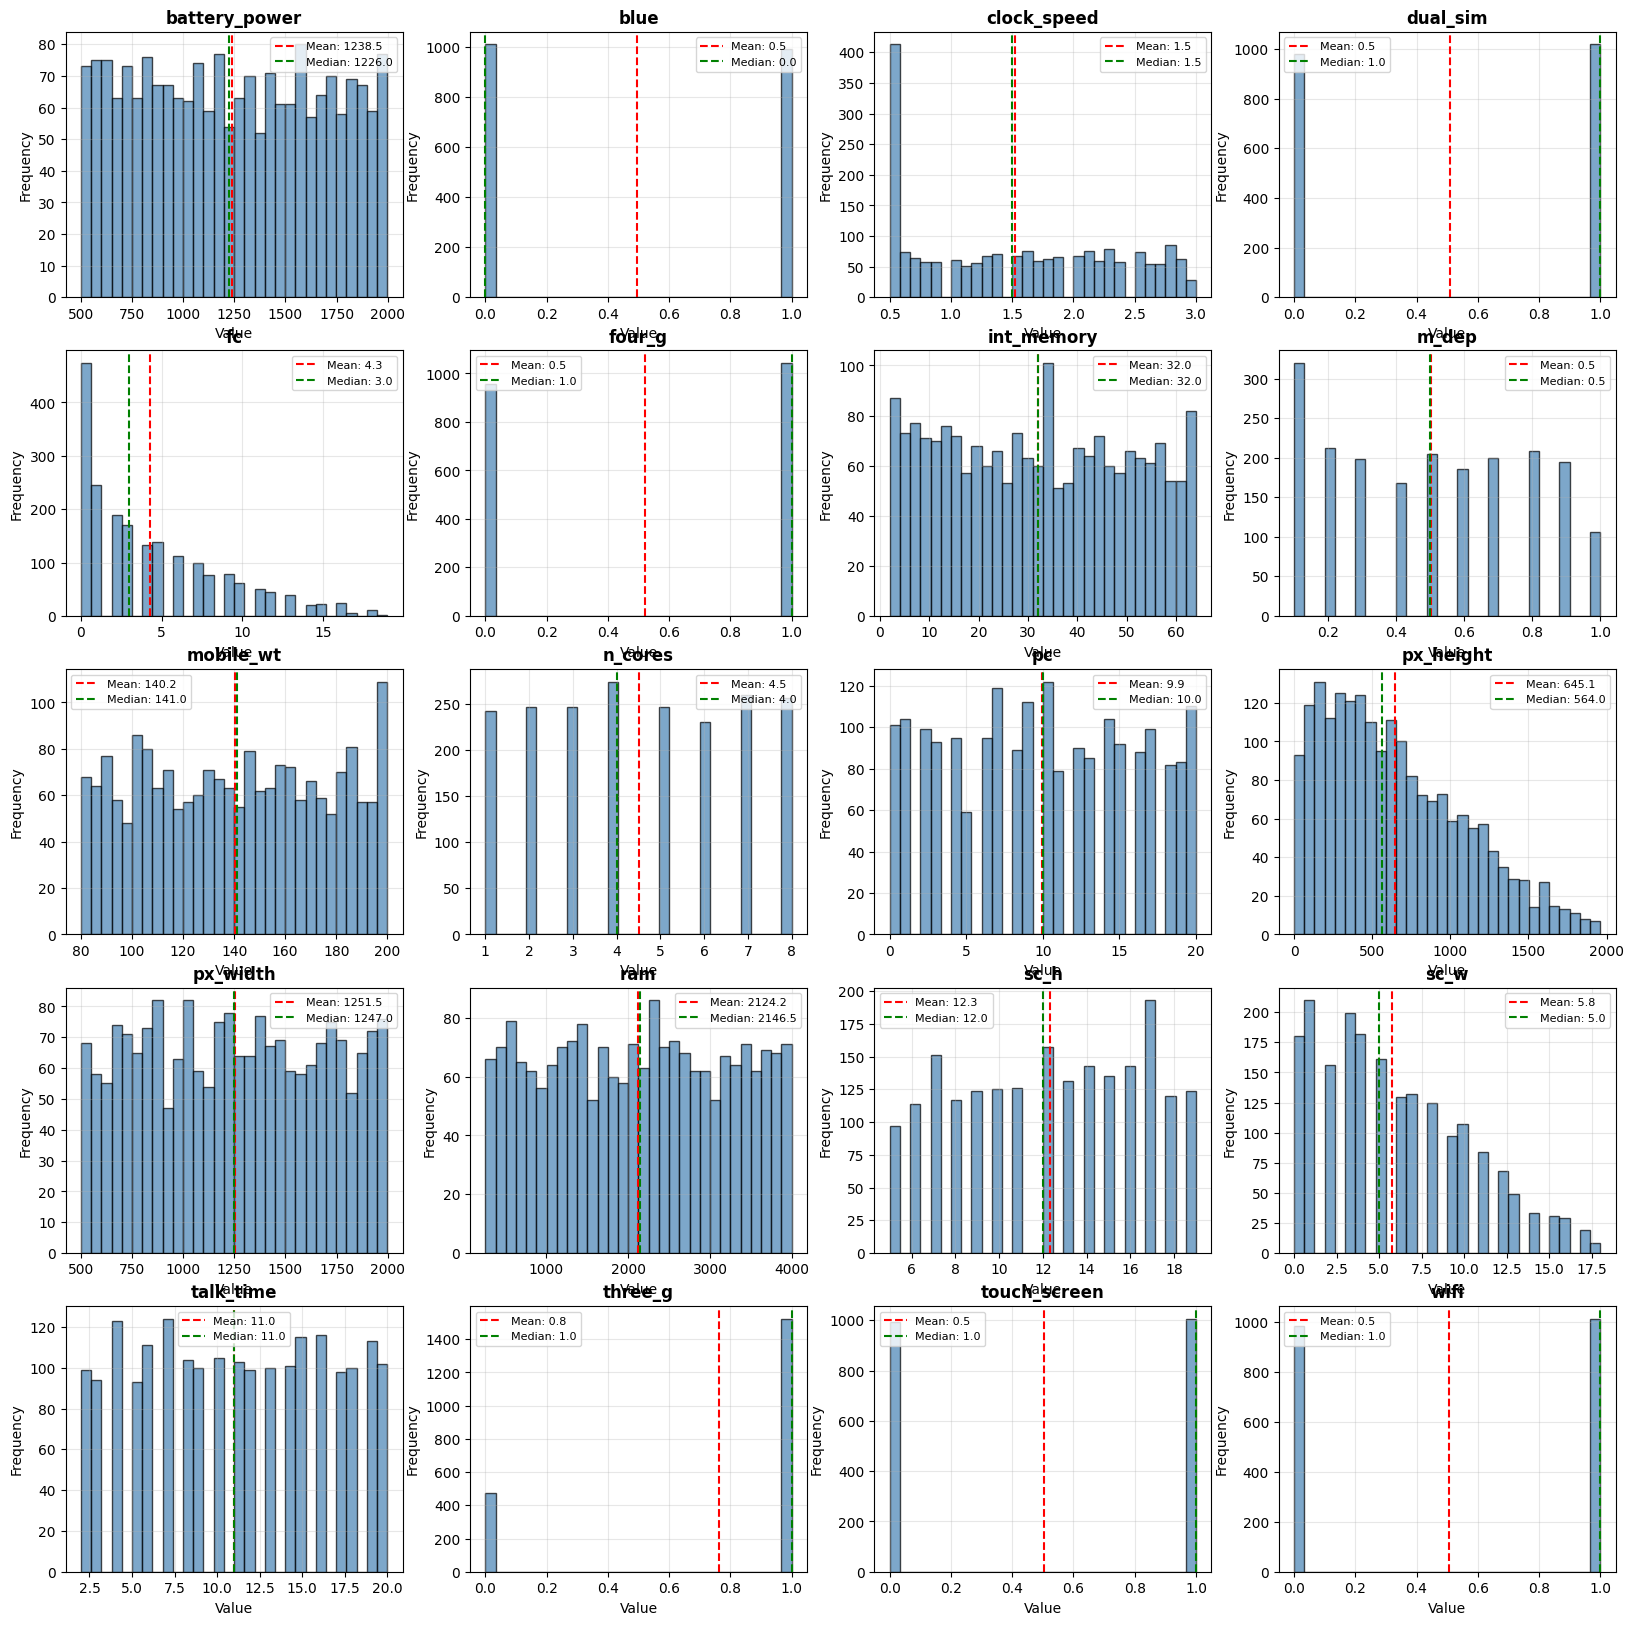

In [49]:


n_features = len(numeric_features)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for idx, feature in enumerate(numeric_features):
    axes[idx].hist(df[feature], bins=30, alpha=0.7, color='steelblue', edgecolor='black')
    axes[idx].set_title(f'{feature}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Value', fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].grid(alpha=0.3)

    mean_val = df[feature].mean()
    median_val = df[feature].median()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.1f}')
    axes[idx].legend(fontsize=8)

In [50]:
outlier_df = pd.DataFrame(outlier_summary)
print("\nOutlier Summary:")
print(outlier_df.to_string(index=False))


Outlier Summary:
      Feature  Outliers  Percentage
battery_power         0        0.00
         blue         0        0.00
  clock_speed         0        0.00
     dual_sim         0        0.00
           fc        18        0.90
       four_g         0        0.00
   int_memory         0        0.00
        m_dep         0        0.00
    mobile_wt         0        0.00
      n_cores         0        0.00
           pc         0        0.00
    px_height         2        0.10
     px_width         0        0.00
          ram         0        0.00
         sc_h         0        0.00
         sc_w         0        0.00
    talk_time         0        0.00
      three_g       477       23.85
 touch_screen         0        0.00
         wifi         0        0.00
battery_power         0        0.00
         blue         0        0.00
  clock_speed         0        0.00
     dual_sim         0        0.00
           fc        18        0.90
       four_g         0        0.00
battery_po

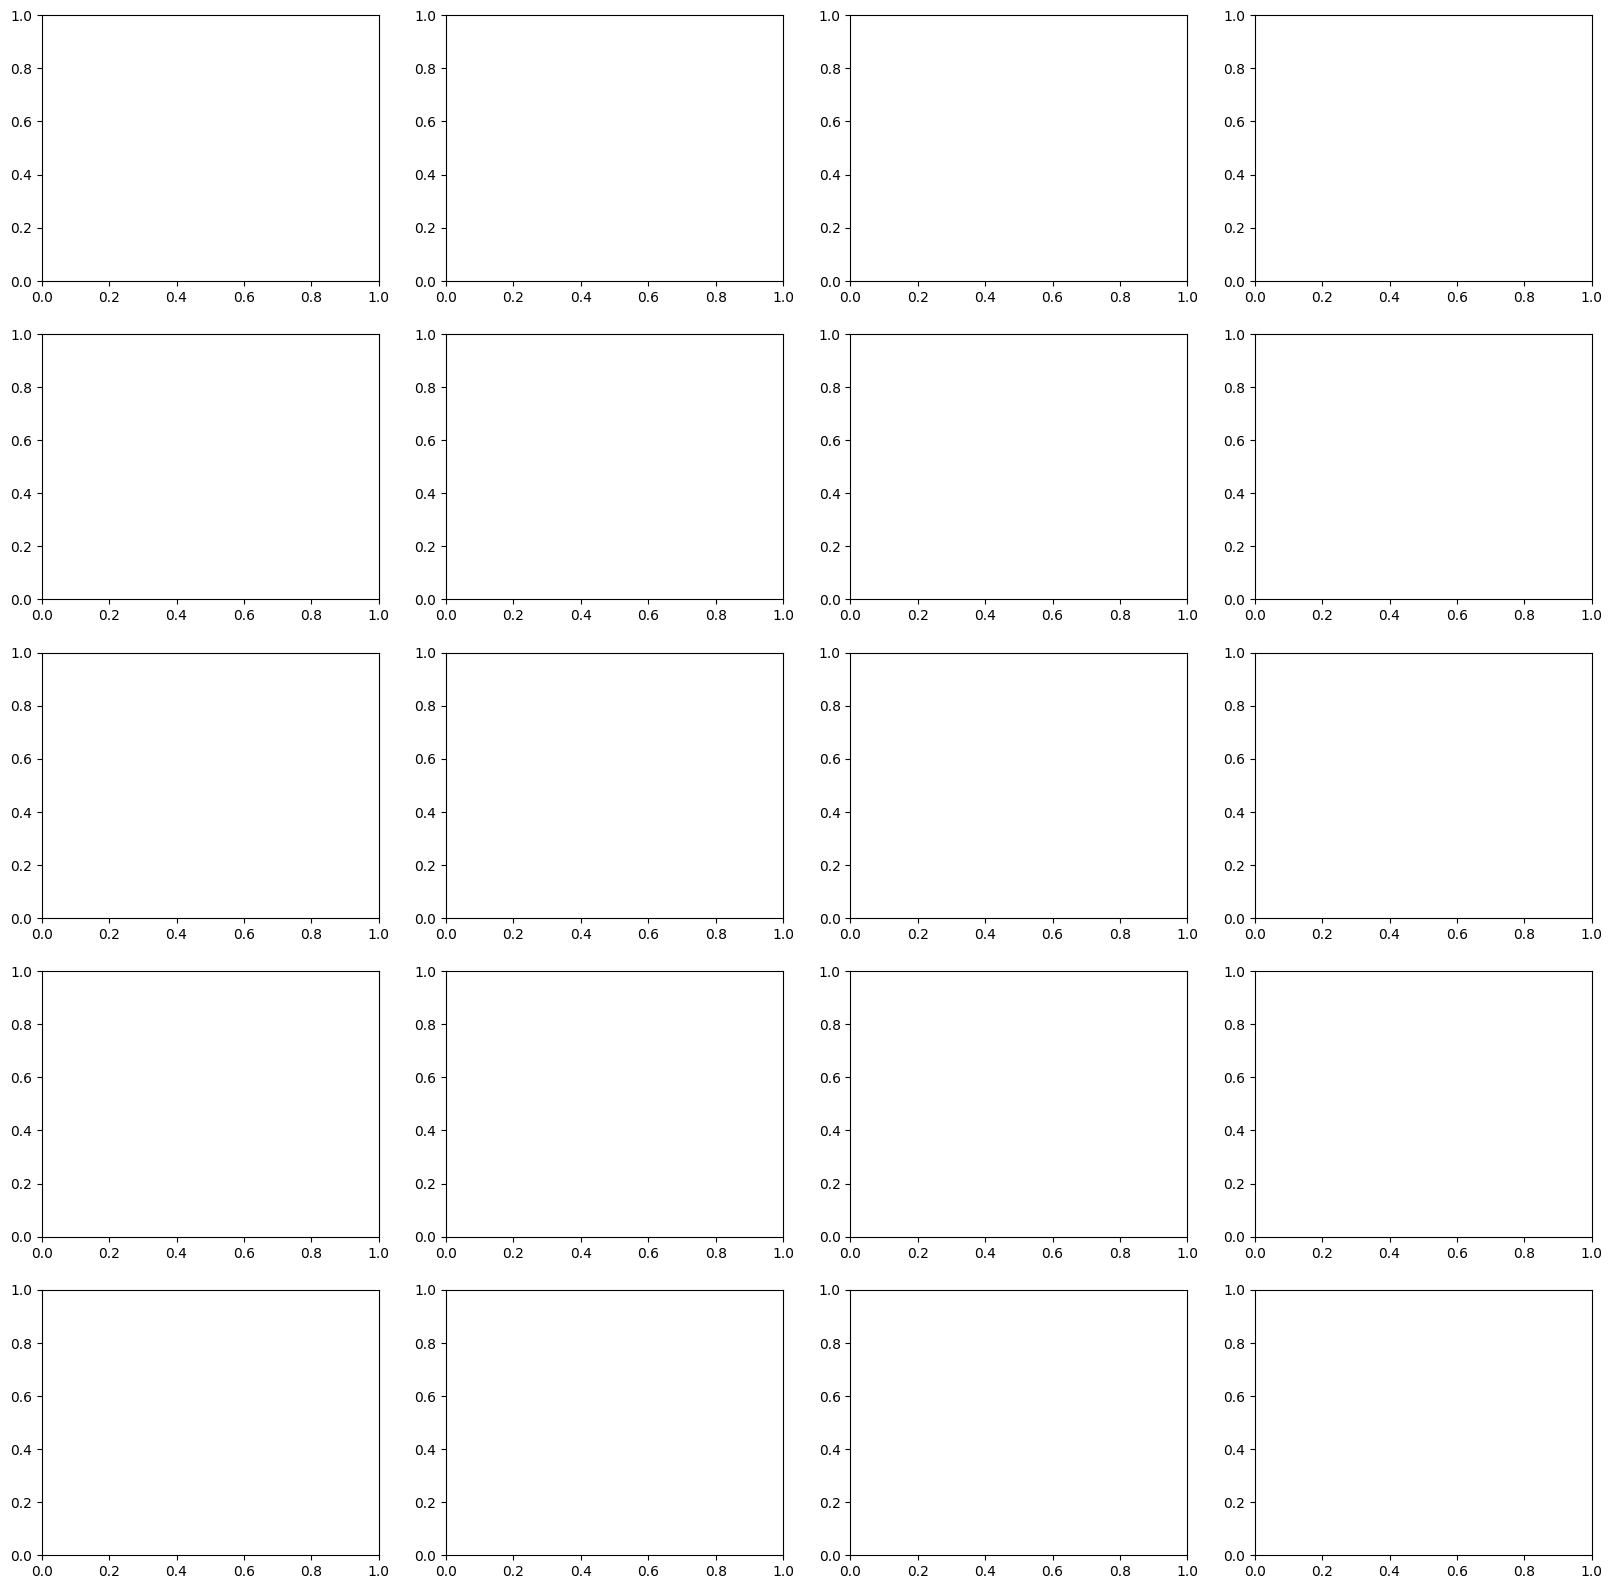

In [51]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

In [52]:
binary_features = []
for col in numeric_features:
    unique_vals = df[col].unique()
    if len(unique_vals) == 2 and set(unique_vals).issubset({0, 1}):
        binary_features.append(col)



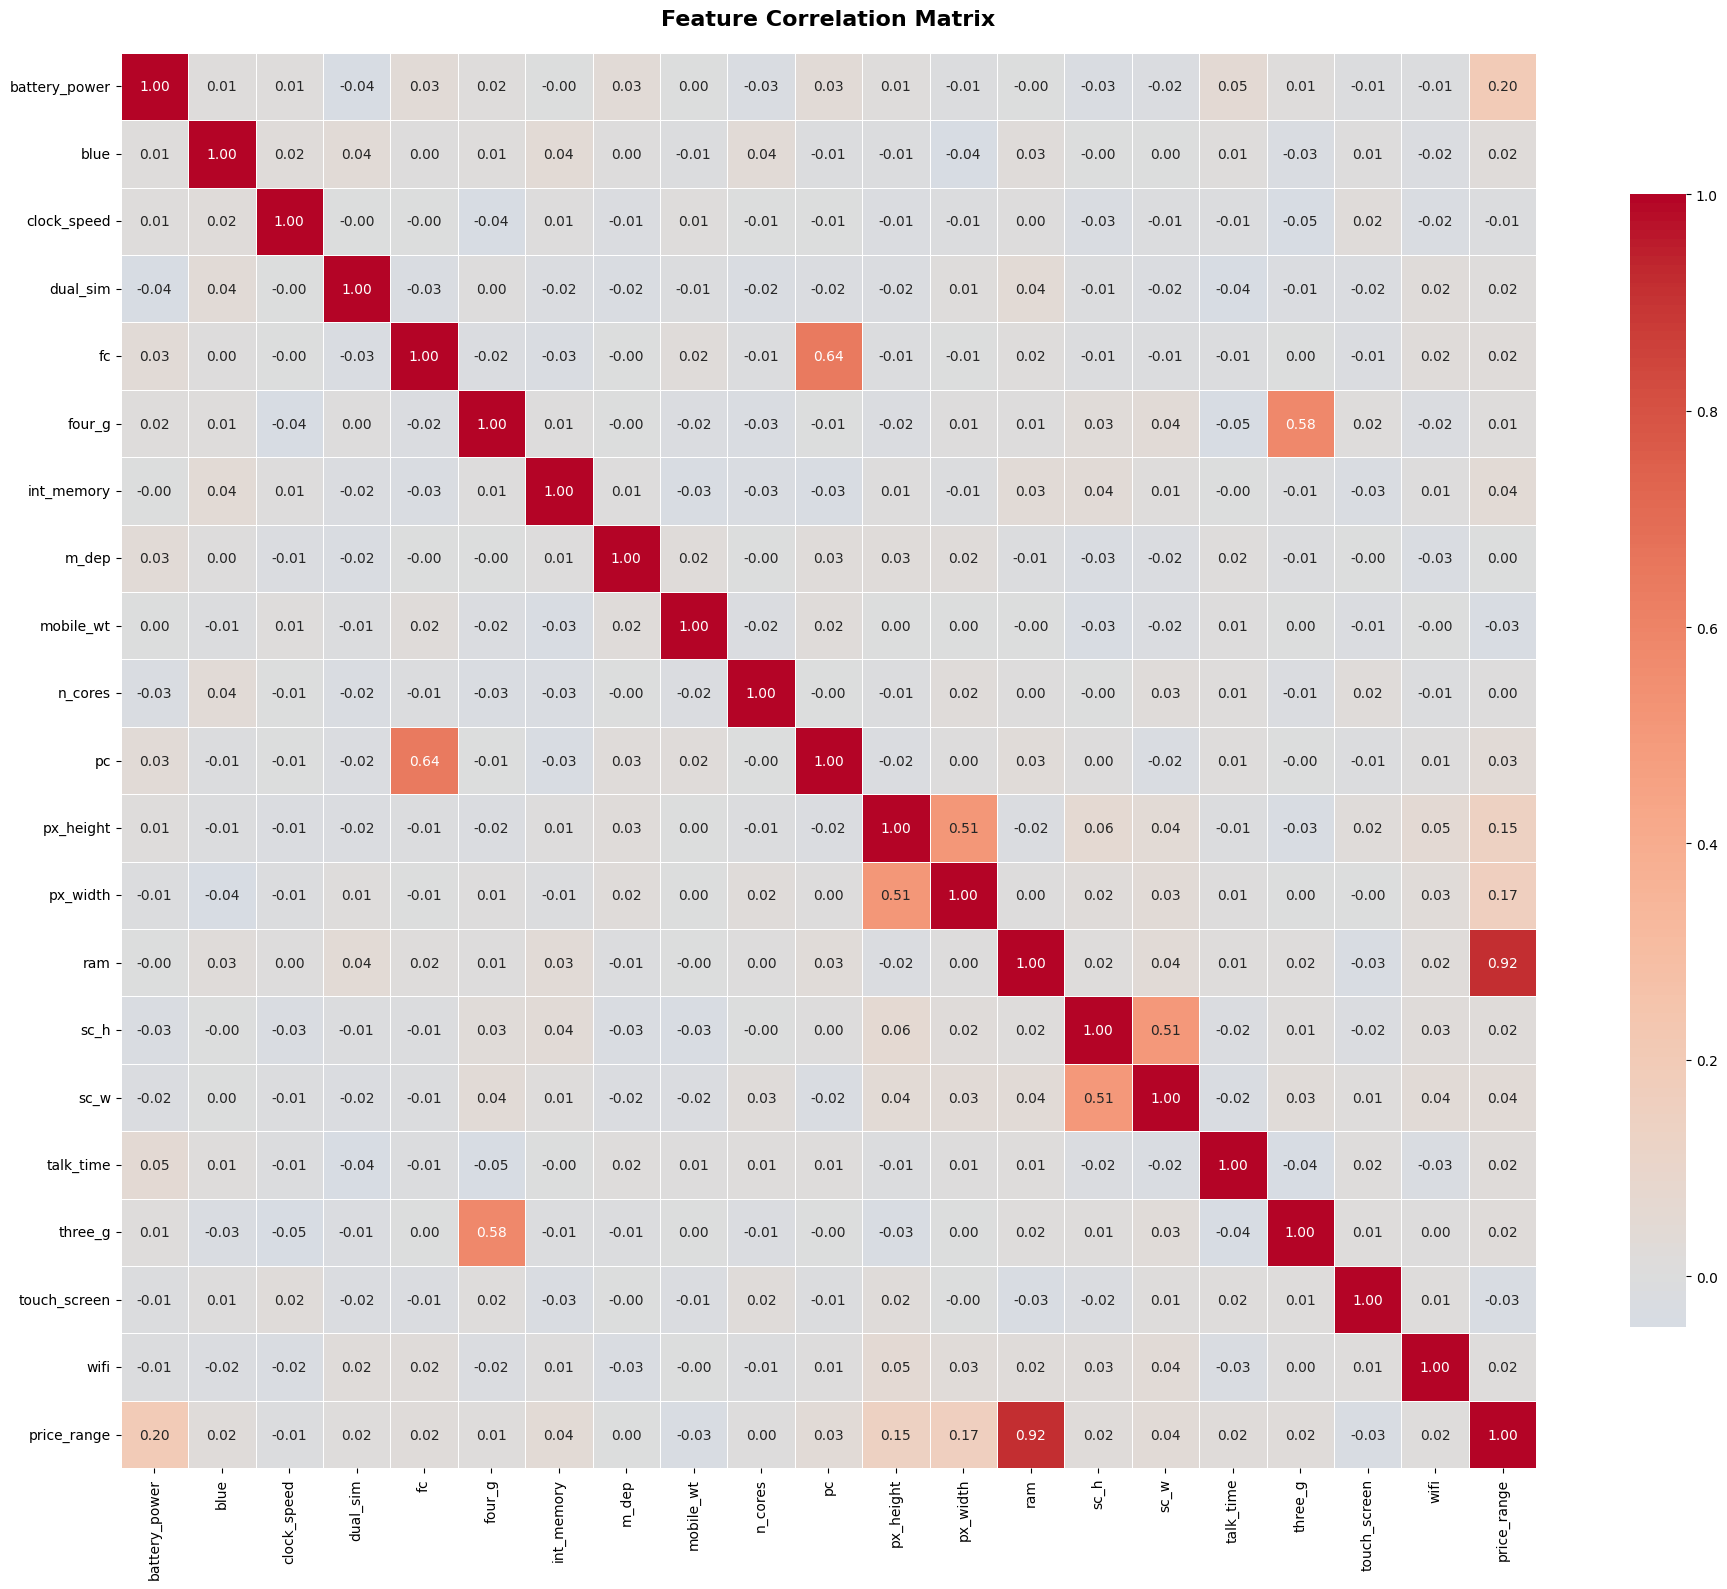

In [53]:
correlation_matrix = df.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Count')

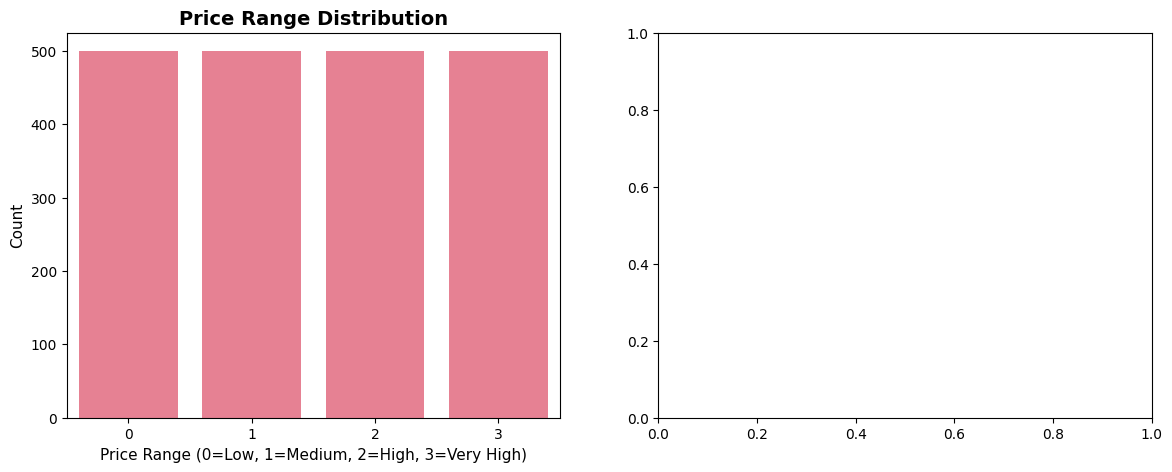

In [54]:


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='price_range', data=df, ax=axes[0])
axes[0].set_title('Price Range Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price Range (0=Low, 1=Medium, 2=High, 3=Very High)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)

In [55]:
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
axes[1].pie(class_counts, labels=['Low (0)', 'Medium (1)', 'High (2)', 'Very High (3)'],
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Price Range Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

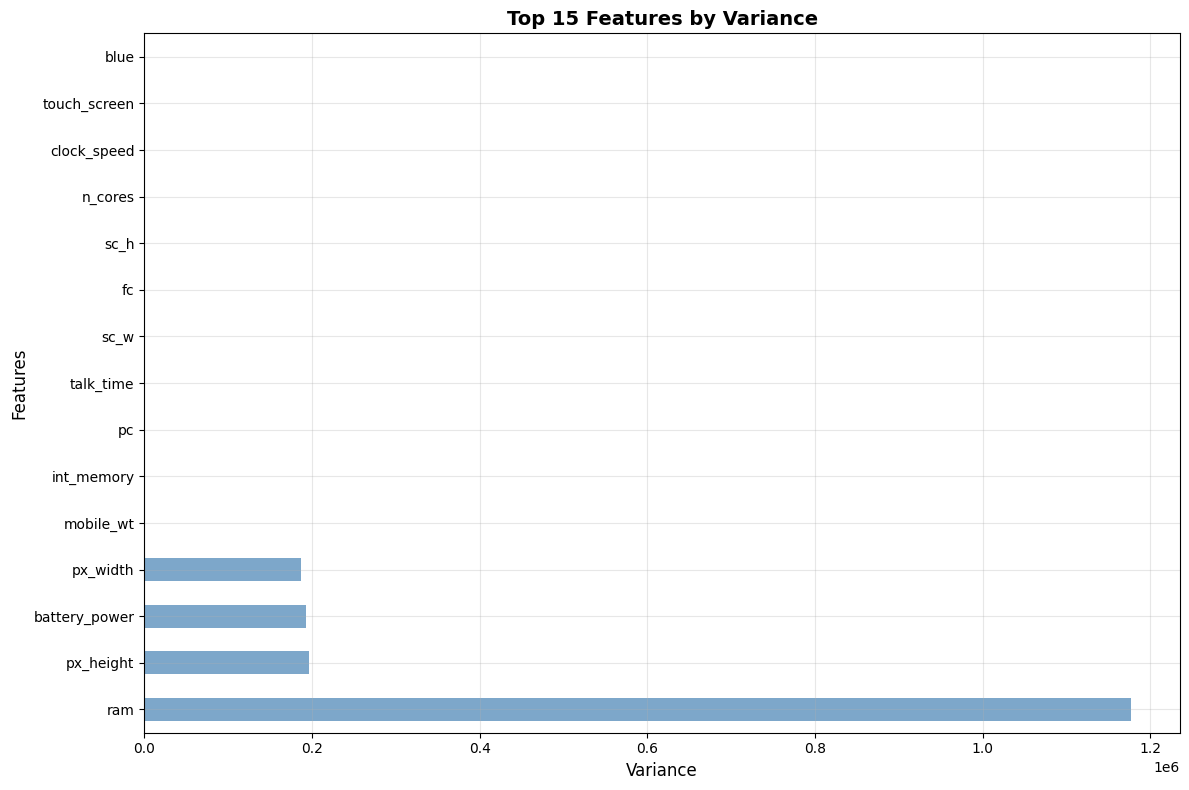

In [56]:
plt.figure(figsize=(12, 8))
variances.head(15).plot(kind='barh', color='steelblue', alpha=0.7)
plt.xlabel('Variance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Top 15 Features by Variance', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

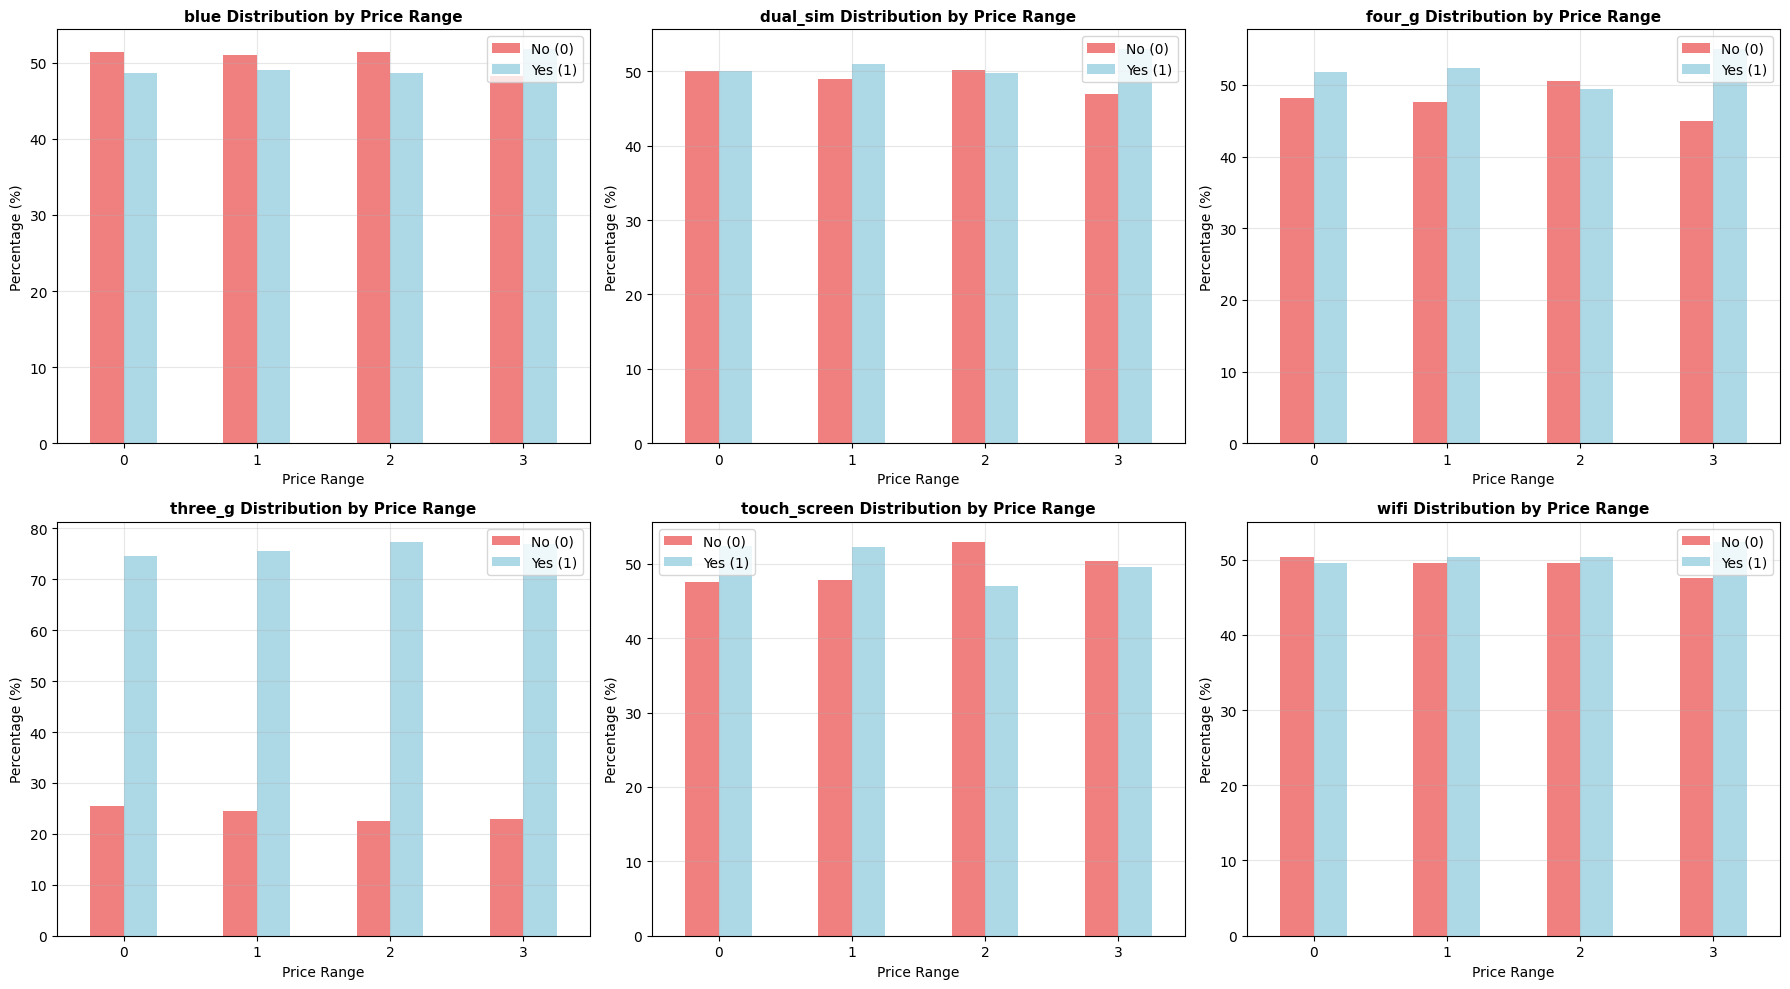

In [57]:
if binary_features:

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for idx, feature in enumerate(binary_features[:6]):

        cross_tab = pd.crosstab(df['price_range'], df[feature], normalize='index') * 100
        cross_tab.plot(kind='bar', ax=axes[idx], color=['lightcoral', 'lightblue'])
        axes[idx].set_title(f'{feature} Distribution by Price Range', fontsize=11, fontweight='bold')
        axes[idx].set_xlabel('Price Range', fontsize=10)
        axes[idx].set_ylabel('Percentage (%)', fontsize=10)
        axes[idx].legend(['No (0)', 'Yes (1)'], loc='best')
        axes[idx].grid(alpha=0.3)
        axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=0)

    for idx in range(len(binary_features[:6]), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()


Creating pairplot for top 5 features: ['ram', 'battery_power', 'px_width', 'px_height', 'int_memory']


<Figure size 1600x1600 with 0 Axes>

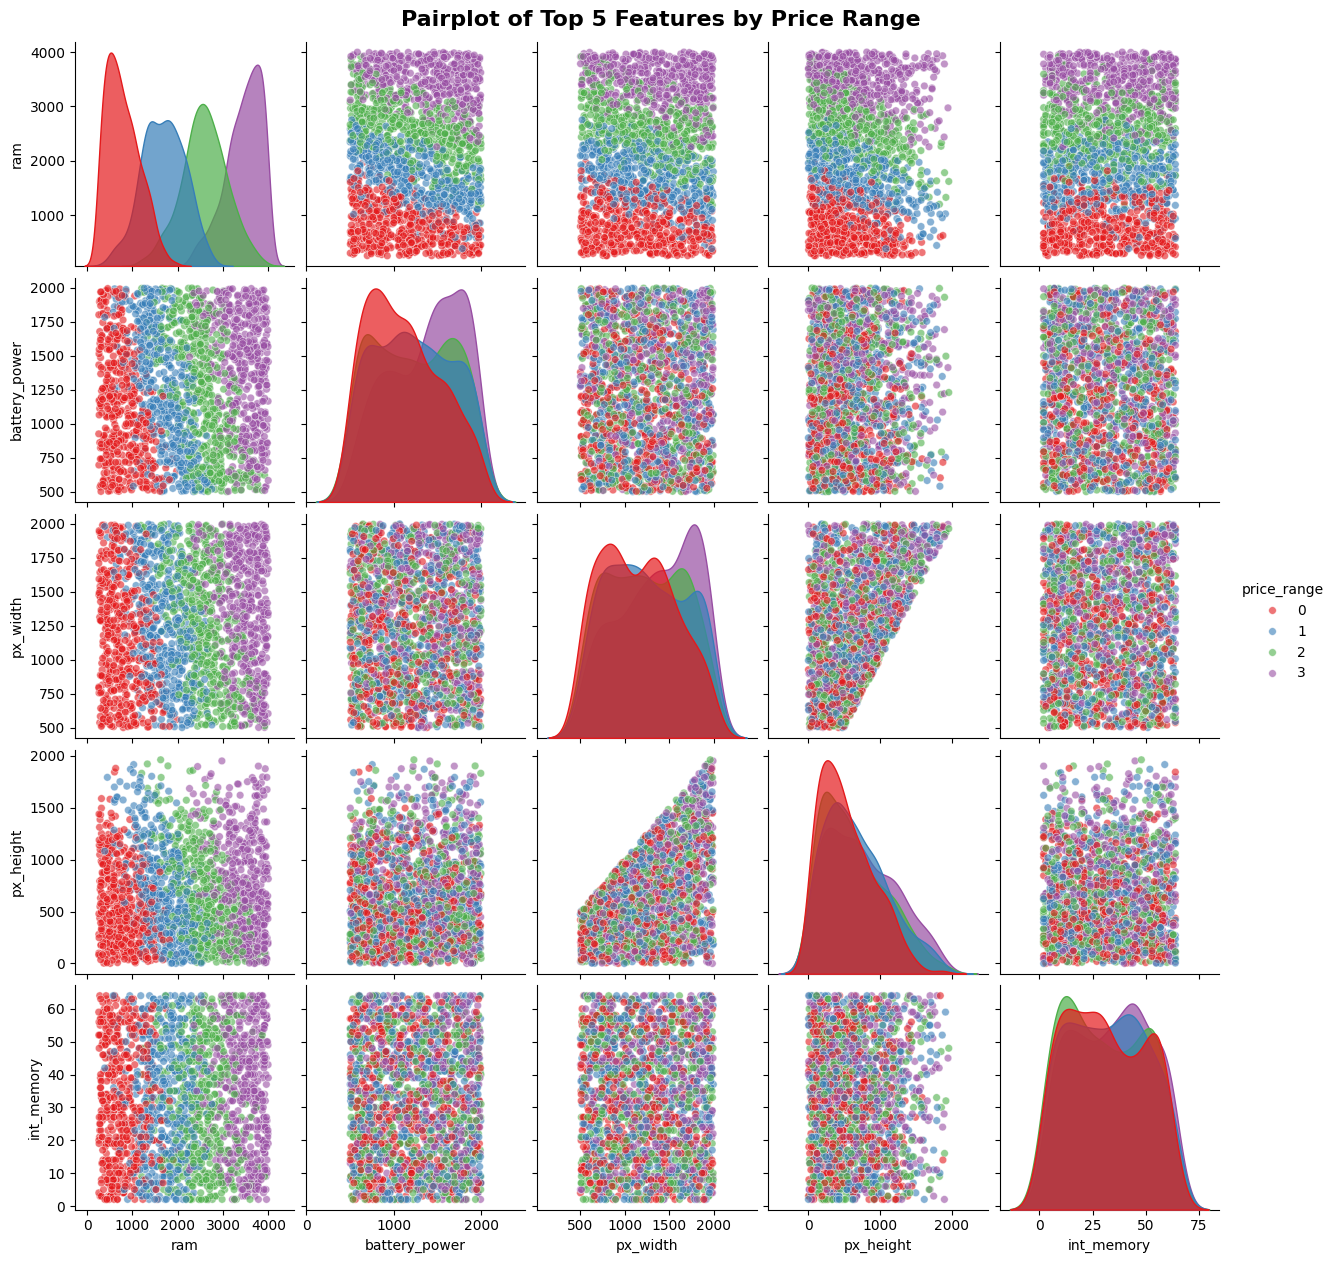

In [58]:
top_5_features = target_corr[1:6].index.tolist()
pairplot_data = df[top_5_features + ['price_range']]

print(f"\nCreating pairplot for top 5 features: {top_5_features}")

plt.figure(figsize=(16, 16))
pairplot = sns.pairplot(pairplot_data, hue='price_range',
                        palette='Set1', diag_kind='kde',
                        plot_kws={'alpha': 0.6, 's': 30},
                        diag_kws={'alpha': 0.7})
pairplot.fig.suptitle('Pairplot of Top 5 Features by Price Range',
                      fontsize=16, fontweight='bold', y=1.01)
plt.show()


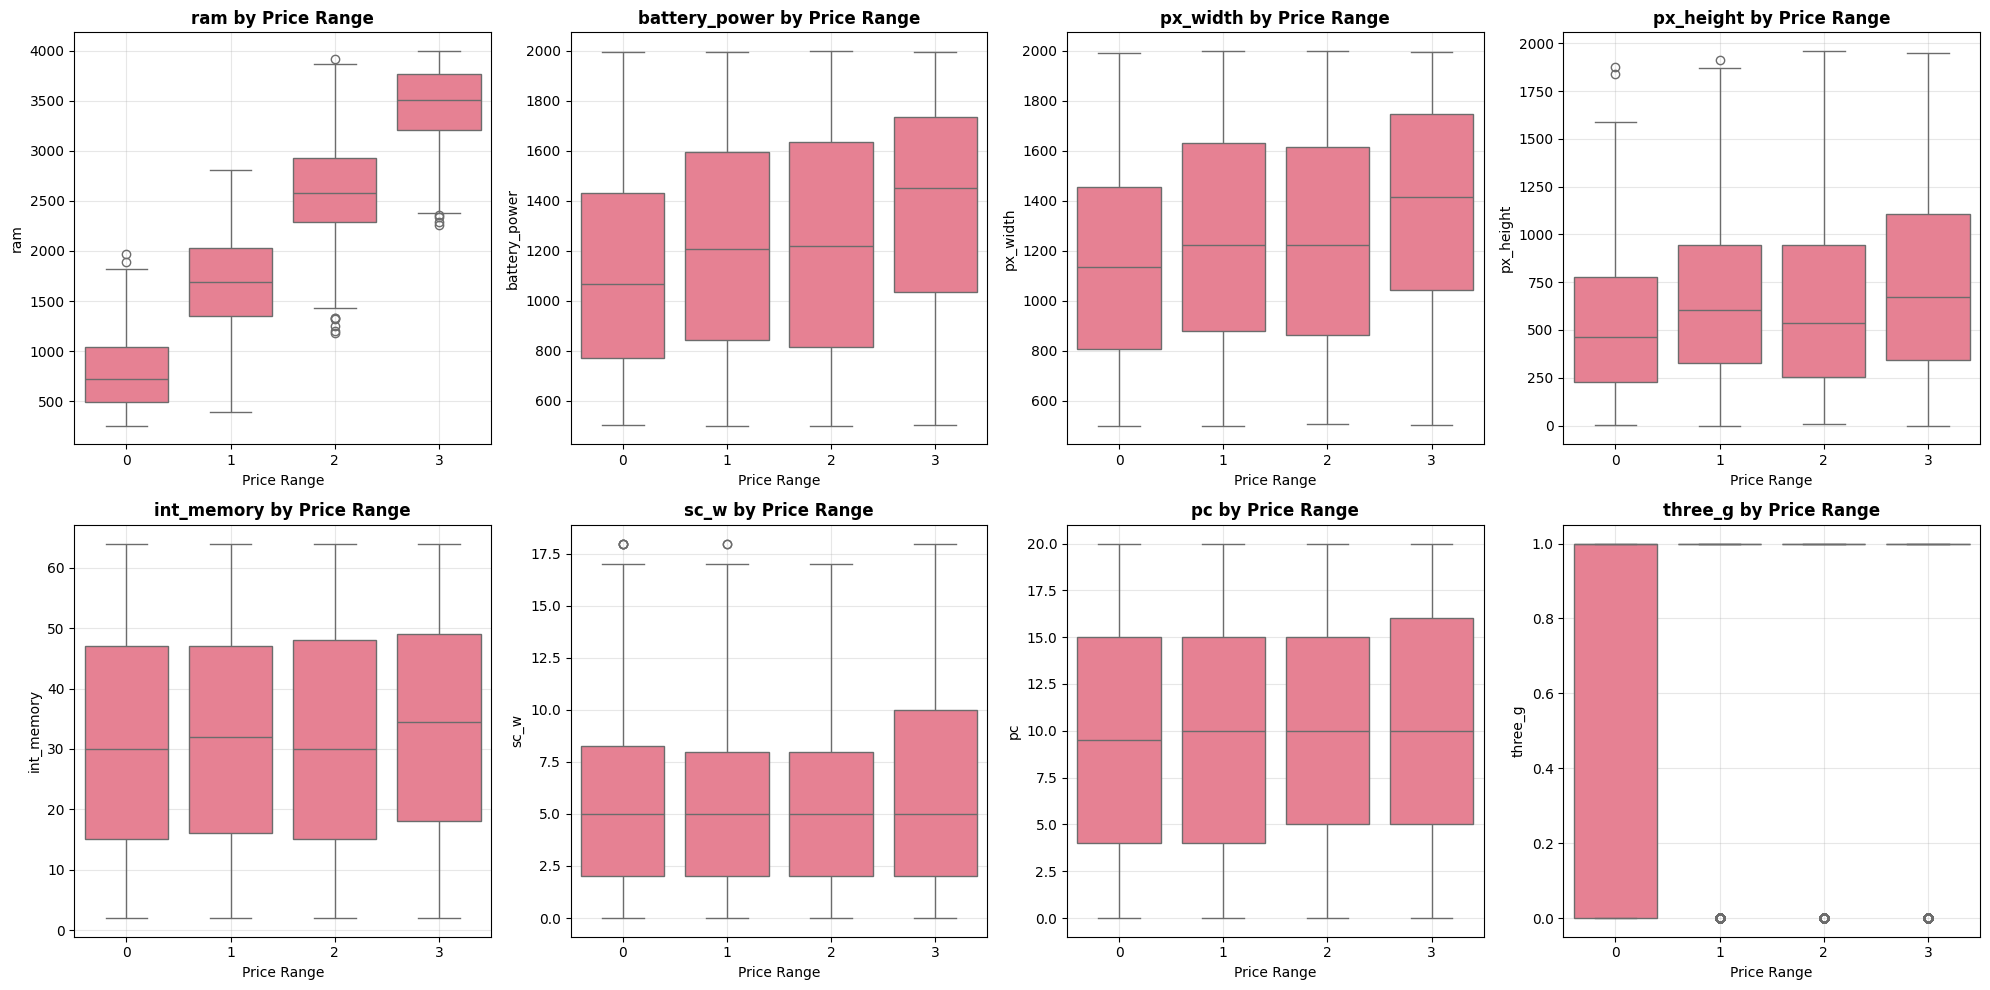

In [59]:
top_features_for_viz = target_corr[1:9].index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_features_for_viz):
    sns.boxplot(x='price_range', y=feature, data=df, ax=axes[idx])
    axes[idx].set_title(f'{feature} by Price Range', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Price Range', fontsize=10)
    axes[idx].set_ylabel(feature, fontsize=10)
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

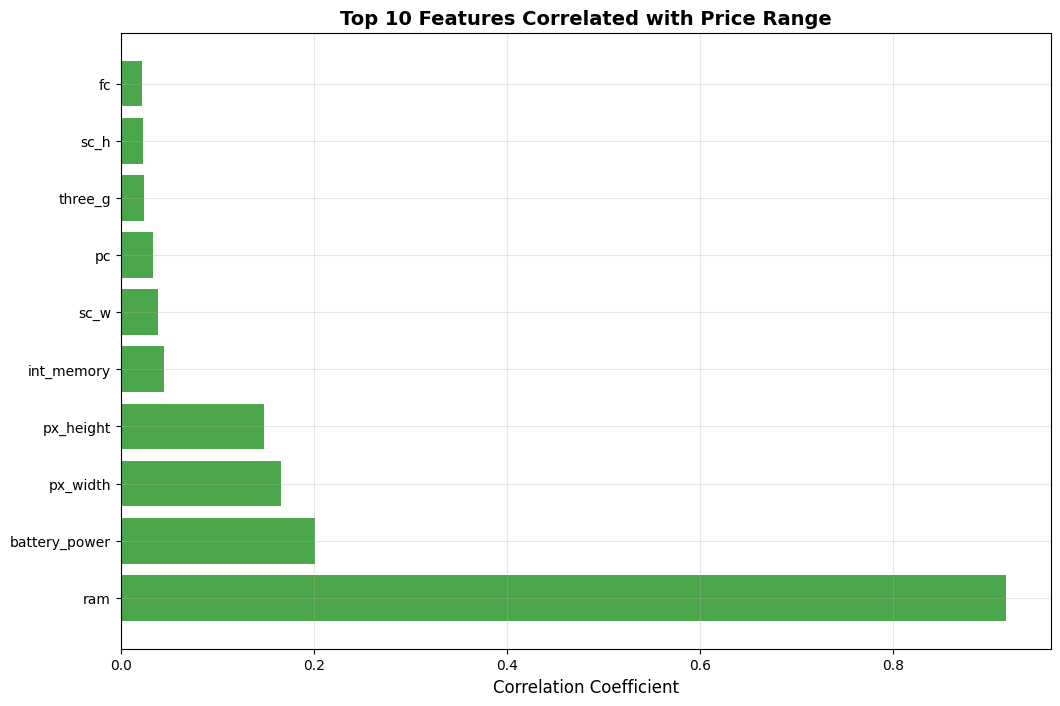

In [60]:
top_n = 10
top_features = target_corr[1:top_n+1]

plt.figure(figsize=(12, 8))
colors = ['green' if x > 0 else 'red' for x in top_features.values]
plt.barh(range(len(top_features)), top_features.values, color=colors, alpha=0.7)
plt.yticks(range(len(top_features)), top_features.index)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.title(f'Top {top_n} Features Correlated with Price Range', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(alpha=0.3)

In [65]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [67]:
from sklearn.model_selection import train_test_split

In [68]:
X = df.drop('price_range',axis=1)

In [69]:
y = df['price_range']

In [83]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=101,stratify=y
)

In [84]:
from sklearn.preprocessing import StandardScaler

In [85]:
from sklearn.ensemble import RandomForestClassifier


In [86]:
from sklearn.pipeline import  Pipeline

In [87]:
pipe = Pipeline([
    ('scaler',StandardScaler()),
    ('model',RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
    ))

    ]
)

In [88]:
pipe.fit(X_train,y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [89]:
y_pred = pipe.predict(X_test)

In [95]:
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay,classification_report

In [94]:
accuracy_score(y_test,y_pred)

0.885

In [97]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      0.92      0.94       100
           1       0.84      0.87      0.86       100
           2       0.84      0.81      0.83       100
           3       0.90      0.94      0.92       100

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.88       400
weighted avg       0.89      0.89      0.88       400

